In [1]:
import re
import string
import numpy as np
import pandas as pd

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from textblob import TextBlob

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\siddh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
Dataset=pd.read_csv("university_query_train.csv")
Dataset.shape

(5000, 5)

In [ ]:
from sklearn.base import BaseEstimator,TransformerMixin
class Preprocess(BaseEstimator,TransformerMixin):
    def __init__(self):
        self.Punctuations=set(string.punctuation)
        self.ShortForm={"$" : " dollar ",
                        "€" : " euro ",
                        "4ao" : "for adults only",
                        "a.m" : "before midday",
                        "a3" : "anytime anywhere anyplace",
                        "aamof" : "as a matter of fact",
                        "acct" : "account",
                        "adih" : "another day in hell",
                        "afaic" : "as far as i am concerned",
                        "afaict" : "as far as i can tell",
                        "afaik" : "as far as i know",
                        "afair" : "as far as i remember",
                        "afk" : "away from keyboard",
                        "app" : "application",
                        "approx" : "approximately",
                        "apps" : "applications",
                        "asap" : "as soon as possible",
                        "asl" : "age, sex, location",
                        "atk" : "at the keyboard",
                        "ave." : "avenue",
                        "aymm" : "are you my mother",
                        "ayor" : "at your own risk", 
                        "b&b" : "bed and breakfast",
                        "b+b" : "bed and breakfast",
                        "b.c" : "before christ",
                        "b2b" : "business to business",
                        "b2c" : "business to customer",
                        "b4" : "before",
                        "b4n" : "bye for now",
                        "b@u" : "back at you",
                        "bae" : "before anyone else",
                        "bak" : "back at keyboard",
                        "bbbg" : "bye bye be good",
                        "bbc" : "british broadcasting corporation",
                        "bbias" : "be back in a second",
                        "bbl" : "be back later",
                        "bbs" : "be back soon",
                        "be4" : "before",
                        "bfn" : "bye for now",
                        "blvd" : "boulevard",
                        "bout" : "about",
                        "brb" : "be right back",
                        "bros" : "brothers",
                        "brt" : "be right there",
                        "bsaaw" : "big smile and a wink",
                        "btw" : "by the way",
                        "bwl" : "bursting with laughter",
                        "c/o" : "care of",
                        "cet" : "central european time",
                        "cf" : "compare",
                        "cia" : "central intelligence agency",
                        "csl" : "can not stop laughing",
                        "cu" : "see you",
                        "cul8r" : "see you later",
                        "cv" : "curriculum vitae",
                        "cwot" : "complete waste of time",
                        "cya" : "see you",
                        "cyt" : "see you tomorrow",
                        "dae" : "does anyone else",
                        "dbmib" : "do not bother me i am busy",
                        "diy" : "do it yourself",
                        "dm" : "direct message",
                        "dwh" : "during work hours",
                        "e123" : "easy as one two three",
                        "eet" : "eastern european time",
                        "eg" : "example",
                        "embm" : "early morning business meeting",
                        "encl" : "enclosed",
                        "encl." : "enclosed",
                        "etc" : "and so on",
                        "faq" : "frequently asked questions",
                        "fawc" : "for anyone who cares",
                        "fb" : "facebook",
                        "fc" : "fingers crossed",
                        "fig" : "figure",
                        "fimh" : "forever in my heart", 
                        "ft." : "feet",
                        "ft" : "featuring",
                        "ftl" : "for the loss",
                        "ftw" : "for the win",
                        "fwiw" : "for what it is worth",
                        "fyi" : "for your information",
                        "g9" : "genius",
                        "gahoy" : "get a hold of yourself",
                        "gal" : "get a life",
                        "gcse" : "general certificate of secondary education",
                        "gfn" : "gone for now",
                        "gg" : "good game",
                        "gl" : "good luck",
                        "glhf" : "good luck have fun",
                        "gmt" : "greenwich mean time",
                        "gmta" : "great minds think alike",
                        "gn" : "good night",
                        "g.o.a.t" : "greatest of all time",
                        "goat" : "greatest of all time",
                        "goi" : "get over it",
                        "gps" : "global positioning system",
                        "gr8" : "great",
                        "gratz" : "congratulations",
                        "gyal" : "girl",
                        "h&c" : "hot and cold",
                        "hp" : "horsepower",
                        "hr" : "hour",
                        "hrh" : "his royal highness",
                        "ht" : "height",
                        "ibrb" : "i will be right back",
                        "ic" : "i see",
                        "icq" : "i seek you",
                        "icymi" : "in case you missed it",
                        "idc" : "i do not care",
                        "idgadf" : "i do not give a damn fuck",
                        "idgaf" : "i do not give a fuck",
                        "idk" : "i do not know",
                        "ie" : "that is",
                        "i.e" : "that is",
                        "ifyp" : "i feel your pain",
                        "IG" : "instagram",
                        "iirc" : "if i remember correctly",
                        "ilu" : "i love you",
                        "ily" : "i love you",
                        "imho" : "in my humble opinion",
                        "imo" : "in my opinion",
                        "imu" : "i miss you",
                        "iow" : "in other words",
                        "irl" : "in real life",
                        "j4f" : "just for fun",
                        "jic" : "just in case",
                        "jk" : "just kidding",
                        "jsyk" : "just so you know",
                        "l8r" : "later",
                        "lb" : "pound",
                        "lbs" : "pounds",
                        "ldr" : "long distance relationship",
                        "lmao" : "laugh my ass off",
                        "lmfao" : "laugh my fucking ass off",
                        "lol" : "laughing out loud",
                        "ltd" : "limited",
                        "ltns" : "long time no see",
                        "m8" : "mate",
                        "mf" : "motherfucker",
                        "mfs" : "motherfuckers",
                        "mfw" : "my face when",
                        "mofo" : "motherfucker",
                        "mph" : "miles per hour",
                        "mr" : "mister",
                        "mrw" : "my reaction when",
                        "ms" : "miss",
                        "mte" : "my thoughts exactly",
                        "nagi" : "not a good idea",
                        "nbc" : "national broadcasting company",
                        "nbd" : "not big deal",
                        "nfs" : "not for sale",
                        "ngl" : "not going to lie",
                        "nhs" : "national health service",
                        "nrn" : "no reply necessary",
                        "nsfl" : "not safe for life",
                        "nsfw" : "not safe for work",
                        "nth" : "nice to have",
                        "nvr" : "never",
                        "nyc" : "new york city",
                        "oc" : "original content",
                        "og" : "original",
                        "ohp" : "overhead projector",
                        "oic" : "oh i see",
                        "omdb" : "over my dead body",
                        "omg" : "oh my god",
                        "omw" : "on my way",
                        "p.a" : "per annum",
                        "p.m" : "after midday",
                        "pm" : "prime minister",
                        "poc" : "people of color",
                        "pov" : "point of view",
                        "pp" : "pages",
                        "ppl" : "people",
                        "prw" : "parents are watching",
                        "ps" : "postscript",
                        "pt" : "point",
                        "ptb" : "please text back",
                        "pto" : "please turn over",
                        "qpsa" : "what happens", #"que pasa",
                        "ratchet" : "rude",
                        "rbtl" : "read between the lines",
                        "rlrt" : "real life retweet", 
                        "rofl" : "rolling on the floor laughing",
                        "roflol" : "rolling on the floor laughing out loud",
                        "rotflmao" : "rolling on the floor laughing my ass off",
                        "rt" : "retweet",
                        "ruok" : "are you ok",
                        "sfw" : "safe for work",
                        "sk8" : "skate",
                        "smh" : "shake my head",
                        "sq" : "square",
                        "srsly" : "seriously", 
                        "ssdd" : "same stuff different day",
                        "tbh" : "to be honest",
                        "tbs" : "tablespooful",
                        "tbsp" : "tablespooful",
                        "tfw" : "that feeling when",
                        "thks" : "thank you",
                        "tho" : "though",
                        "thx" : "thank you",
                        "tia" : "thanks in advance",
                        "til" : "today i learned",
                        "tl;dr" : "too long i did not read",
                        "tldr" : "too long i did not read",
                        "tmb" : "tweet me back",
                        "tntl" : "trying not to laugh",
                        "ttyl" : "talk to you later",
                        "u" : "you",
                        "u2" : "you too",
                        "u4e" : "yours for ever",
                        "utc" : "coordinated universal time",
                        "w/" : "with",
                        "w/o" : "without",
                        "w8" : "wait",
                        "wassup" : "what is up",
                        "wb" : "welcome back",
                        "wtf" : "what the fuck",
                        "wtg" : "way to go",
                        "wtpa" : "where the party at",
                        "wuf" : "where are you from",
                        "wuzup" : "what is up",
                        "wywh" : "wish you were here",
                        "yd" : "yard",
                        "ygtr" : "you got that right",
                        "ynk" : "you never know",
                        "zzz" : "sleeping bored and tired"
                    }
        
    def _get_stopwords(self): # Causes issues when we n_jobs=-1 is Set...Error: Not Pickable...
            return set(stopwords.words('english'))
    
    def _get_stemmer(self): # Same reason as Stopwaords...
        return PorterStemmer()

    def _get_emoji_pattern(self): # Same reason as Stopwaords...
        return re.compile("["
                u"\U0001F600-\U0001F64F"
                u"\U0001F300-\U0001F5FF"
                u"\U0001F680-\U0001F6FF"
                u"\U0001F1E0-\U0001F1FF"
                u"\U00002702-\U000027B0"
                u"\U000024C2-\U0001F251"
                "]+", flags=re.UNICODE)
    
    def fit(self,Textcolumn,y=None): # Remember Underscore is Important to make it Work with the ColumnTransformer and Pipeline...
        if hasattr(Textcolumn,"columns"):
            self.columns_=Textcolumn.columns
            self.dim_=Textcolumn.shape[1]
        elif hasattr(Textcolumn,"name"):
            self.columns_=None
            self.dim_=1
        else:
            self.columns_=None
            self.dim_=Textcolumn.shape[1] if Textcolumn.ndim>1 else 1
        return self
    
    def transform(self,Textcolumn):
        self.Stopwords=self._get_stopwords()
        self.Stemmer=self._get_stemmer()
        self.Emoji_Pattern=self._get_emoji_pattern()
        if isinstance(Textcolumn,pd.DataFrame):
            Textcolumn=Textcolumn.iloc[:,0]
        elif isinstance(Textcolumn,np.ndarray):
            Textcolumn=pd.Series(Textcolumn.flatten())
        else:
            Textcolumn=pd.Series(Textcolumn)
        return Textcolumn.apply(self.PreprocessText).values.reshape(-1, 1)
        

    def PreprocessText(self,Text):
        if type(Text) is not __builtins__["str"] if isinstance(__builtins__, dict) else type(Text) is not type(""):
            return "" #"The Input is not a String you Cow..."
        
        Text=Text.lower() # Converts to Lowercase...
        Text="".join(ch for ch in Text if ch not in self.Punctuations) # Removes Punctuations...
        Text=" ".join([self.ShortForm.get(word,word) for word in Text.split()]) # Converts ShortForms...
        Text=self.Emoji_Pattern.sub(r'',Text) # Removes Emojis...
        Text=TextBlob(Text).correct().string # Corrects Spellings...
        Text=" ".join([self.Stemmer.stem(word) for word in Text.split() if word not in self.Stopwords]) # Stemming and Removes Stopwords...
        return Text

In [4]:
#The traceback AttributeError: 'WordListCorpusReader' object has no attribute '_unload' tells us exactly what went wrong: 
#The NLTK Stopwords and Stemmer objects (which are part of NLTK's WordListCorpusReader) do not like being pickled. 
#They are complex objects linked to your local file system, and they "break" when sent to another process.

#Use n_jobs=1 to prevent this Error...

In [5]:
Dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Query_ID          5000 non-null   int64 
 1   Student_Query     5000 non-null   object
 2   Department        5000 non-null   object
 3   Days_To_Deadline  5000 non-null   int64 
 4   Priority_Label    5000 non-null   object
dtypes: int64(2), object(3)
memory usage: 195.4+ KB


In [12]:
print(Dataset['Student_Query'].nunique())

15


In [13]:
Y=Dataset["Priority_Label"].map({"Low":0,"Medium":1,"High":2})
X=Dataset.drop(columns=["Priority_Label","Query_ID"])

In [ ]:
class ArrayFlattener(BaseEstimator,TransformerMixin):
    def fit(self,X,y=None):
        return self
    def transform(self,X):
        import numpy as np
        return np.array(X).ravel() # CountVectorizer/TfidfVectorizer Needs 1D...


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,shuffle=True,random_state=32)

QueryProcessor=ColumnTransformer(transformers=[
    ("TextPreprocessing",Preprocess(),["Student_Query"]),
    ("DeptEncoding",OneHotEncoder(drop="first",handle_unknown="ignore"),["Department"])
    ],remainder="passthrough",sparse_threshold=0)
# The issue here is that Preprocess outputs strings and OneHotEncoder outputs numbers — 
# ColumnTransformer can't hstack these into a sparse matrix. 
# Fix it with sparse_threshold=0 to force dense output.

TextVectorizerPipe=Pipeline([
    ("Flatten",ArrayFlattener()),
    #("Vectorizer",CountVectorizer(ngram_range=(1,2),lowercase=False)),
    ("Vectorizer",TfidfVectorizer(ngram_range=(1,2),lowercase=False)),
    ])

QueryVectorizer=ColumnTransformer(transformers=[
    ("VectorizerPipe",TextVectorizerPipe,[0])  
    ],remainder="passthrough")

MyPipe=Pipeline([
    ("Text_Preprocessor",QueryProcessor),
    ("Text_to_Num",QueryVectorizer),
    ("Classifier",LogisticRegression())
])

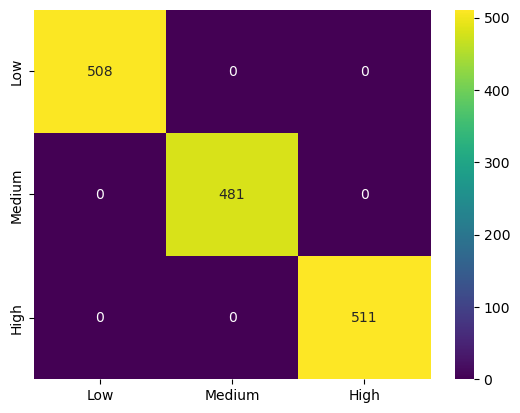

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
MyPipe.fit(X_train,Y_train)
MyPipe.score(X_train,Y_train)
Matrix=confusion_matrix(Y_test,MyPipe.predict(X_test))
sns.heatmap(Matrix,annot=True,fmt="d",cmap="viridis",xticklabels=["Low","Medium","High"],yticklabels=["Low","Medium","High"])
plt.show()

In [19]:
import joblib
joblib.dump(MyPipe,"ModelPipeline.pkl")
Label_Map={0:"Low",1:"Medium",2:"High"}
joblib.dump(Label_Map,'Label_Map.pkl')

['Label_Map.pkl']